### Remap OISST to tx2_3

In [1]:
%matplotlib inline

In [2]:
import xarray as xr
import xesmf
import numpy as np
import datetime
import matplotlib.pyplot as plt

In [3]:
today = datetime.date.today().strftime("%y%m%d")
print(today)

260306


In [4]:
fname = '../mesh/tx2_3v3_grid.nc'
ds_out = xr.open_dataset(fname).rename({'tlon': 'lon','tlat': 'lat', 'qlon': 'lon_b',
                                        'qlat': 'lat_b', 'nx' : 'xh', 'ny' : 'yh',
                                        'depth' : 'z_l', 'tmask':'mask'})
ds_out

<xarray.Dataset> Size: 42MB
Dimensions:  (yh: 480, xh: 540, nxp: 541, nyp: 481)
Dimensions without coordinates: yh, xh, nxp, nyp
Data variables: (12/20)
    lon      (yh, xh) float64 2MB ...
    lat      (yh, xh) float64 2MB ...
    ulon     (yh, nxp) float64 2MB ...
    ulat     (yh, nxp) float64 2MB ...
    vlon     (nyp, xh) float64 2MB ...
    vlat     (nyp, xh) float64 2MB ...
    ...       ...
    tarea    (yh, xh) float64 2MB ...
    mask     (yh, xh) float64 2MB ...
    angle    (yh, xh) float64 2MB ...
    z_l      (yh, xh) float64 2MB ...
    ar       (yh, xh) float64 2MB ...
    egs      (yh, xh) float64 2MB ...
Attributes:
    Description:  CESM MOM6 2/3 degree grid
    Author:       Frank, Fred, Gustavo (gmarques@ucar.edu)
    Created:      2026-03-05T14:49:28.971877
    type:         Glogal 2/3 degree grid file

In [5]:
infile = '/glade/campaign/cgd/oce/datasets/obs/OI.SST.v2/monthly/sst.mean.????.??.nc'
ds_in = xr.open_mfdataset(infile)
ds_in

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 444, lat: 720, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 4kB 1982-01-16 ... 2018-12-16
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    sst      (time, lat, lon) float32 2GB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
Attributes:
    Conventions:    CF-1.5
    title:          NOAA High-resolution Blended Analysis: Daily Values using...
    institution:    NOAA/NCDC
    source:         NOAA/NCDC  ftp://eclipse.ncdc.noaa.gov/pub/OI-daily-v2/
    comment:        Reynolds, et al., 2007: Daily High-Resolution-Blended Ana...
    history:        Mon Dec 23 22:15:20 2019: ncra -F -d time,1,31 sst.day.me...
    references:     https://www.esrl.noaa.gov/psd/data/gridded/data.noaa.oiss...
    dataset_title:  NOAA Daily Optimum Interpolation Sea Surface Temperature
    NCO:            netCDF Operators version 4.8.1 (Homepage = http://nco.sf....

In [6]:
def regrid_tracer(fld, ds_in, ds_out, method='bilinear'):

    regrid = xesmf.Regridder(
        ds_in,
        ds_out,
        method=method,
        periodic=True,
    )
    fld_out = regrid(ds_in[fld])#[0,0,:]#.where(ds_in.lat>ds_out.geolat.min())
    return fld_out

#### Potential temperature

In [7]:
sst = regrid_tracer('sst', ds_in, ds_out).rename('sst')
sst

<xarray.DataArray 'sst' (time: 444, yh: 480, xh: 540)> Size: 460MB
dask.array<astype, shape=(444, 480, 540), dtype=float32, chunksize=(1, 480, 540), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 4kB 1982-01-16 ... 2018-12-16
Dimensions without coordinates: yh, xh
Attributes:
    regrid_method:  bilinear

In [8]:
# add coordinates
sst = sst.assign_coords(geolat=ds_out.lat, geolon=ds_out.lon)
sst

<xarray.DataArray 'sst' (time: 444, yh: 480, xh: 540)> Size: 460MB
dask.array<astype, shape=(444, 480, 540), dtype=float32, chunksize=(1, 480, 540), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 4kB 1982-01-16 ... 2018-12-16
    geolat   (yh, xh) float64 2MB -81.56 -81.56 -81.56 ... 50.27 50.11 49.99
    geolon   (yh, xh) float64 2MB -286.7 -286.0 -285.3 ... 72.97 72.98 73.0
Dimensions without coordinates: yh, xh
Attributes:
    regrid_method:  bilinear

##### Visual inspection
Make sure original and remapped plots look similar.

/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/dask/config.py:786: FutureWarning: Dask configuration key 'allowed-failures' has been deprecated; please use 'distributed.scheduler.allowed-failures' instead
  warnings.warn(


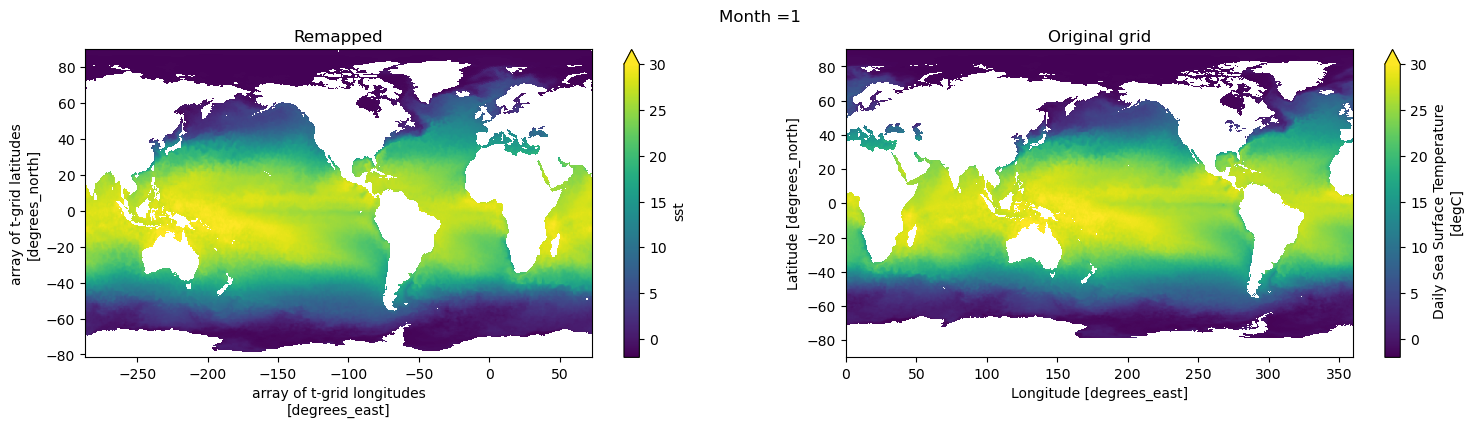

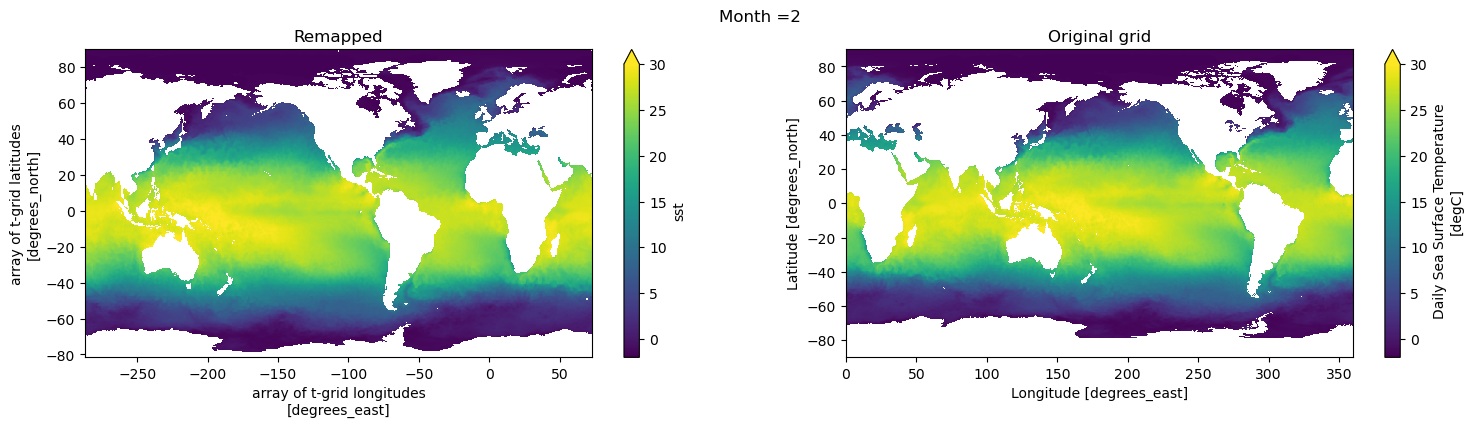

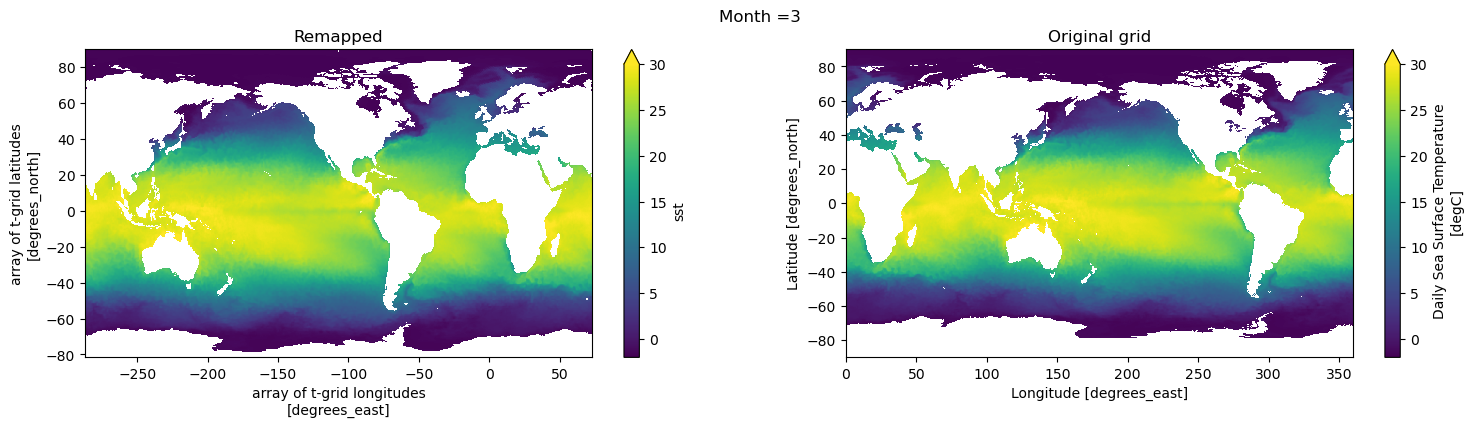

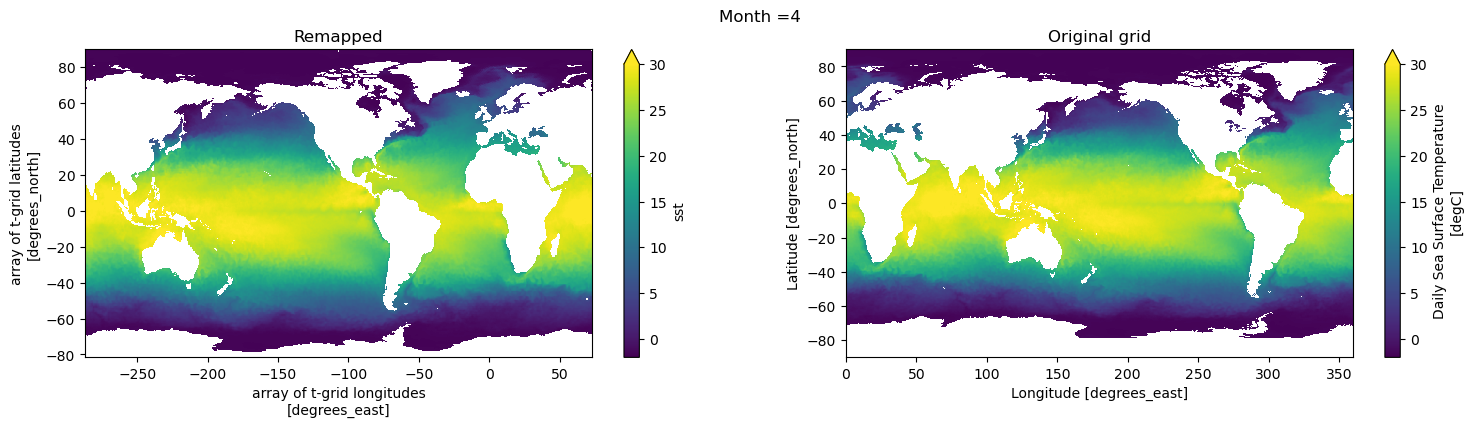

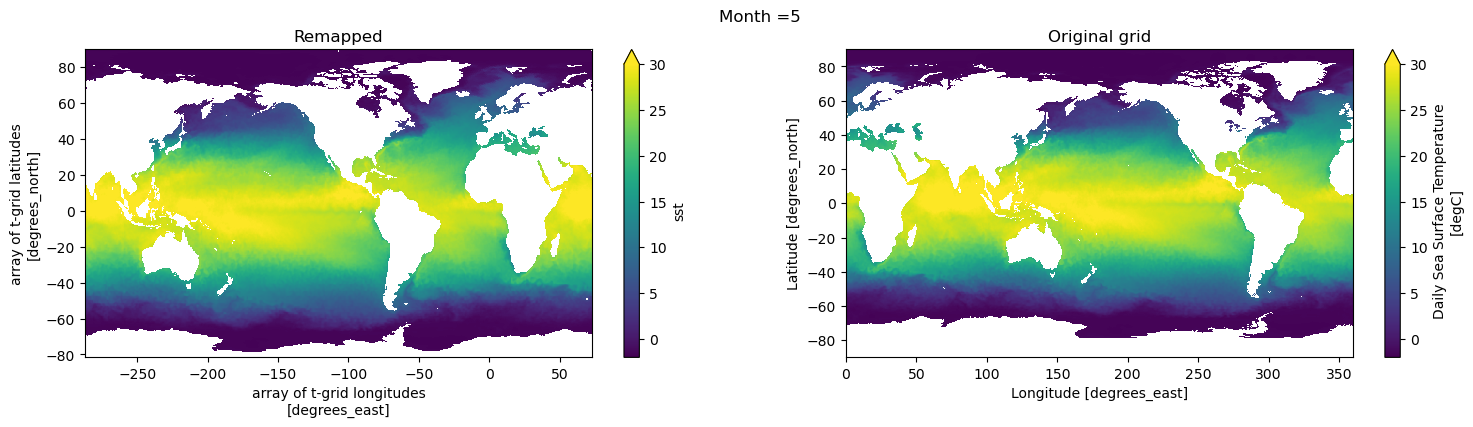

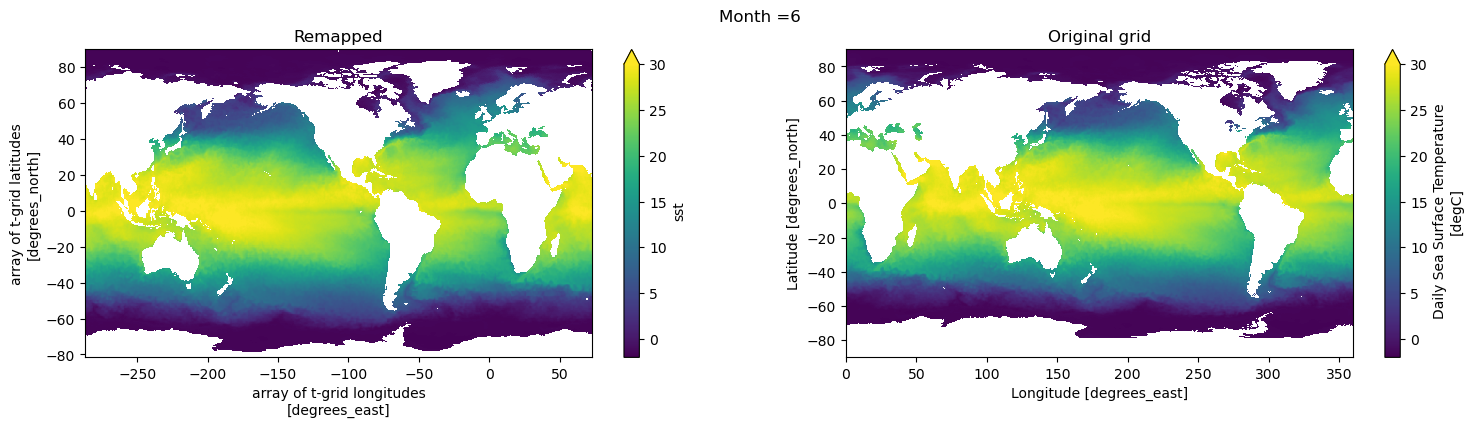

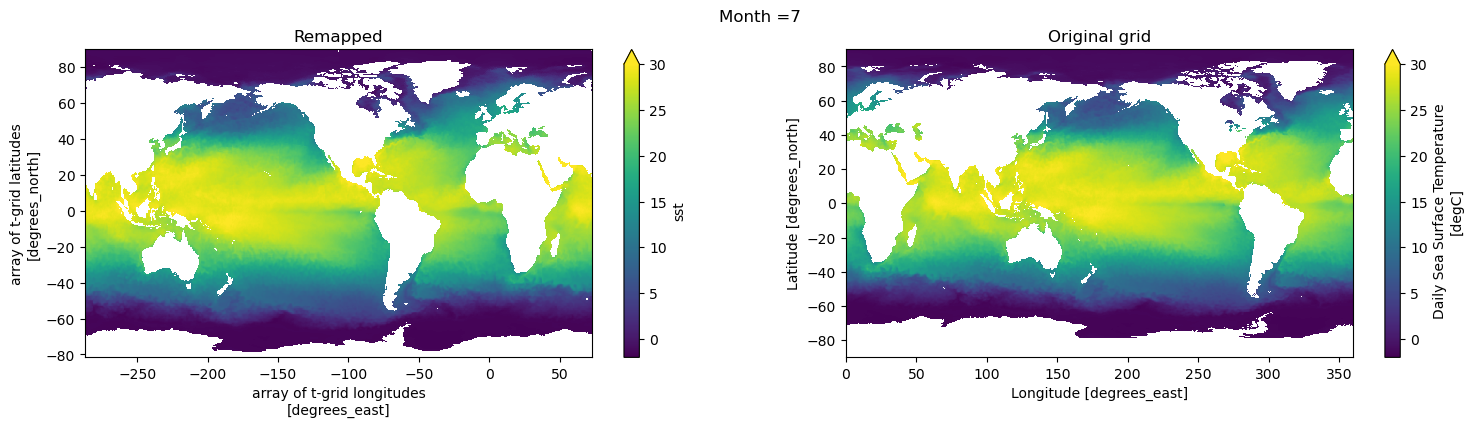

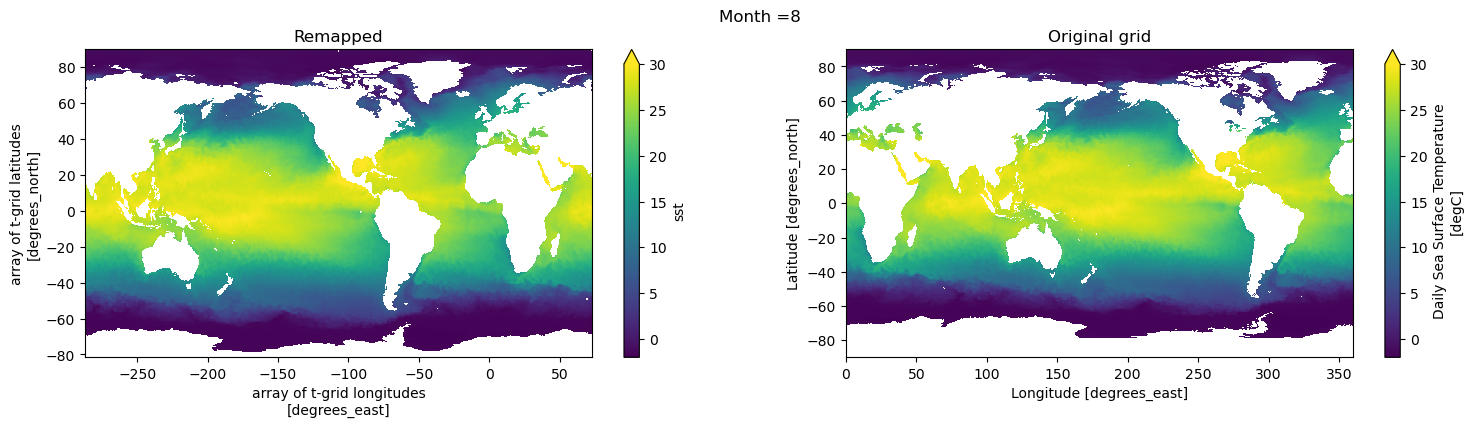

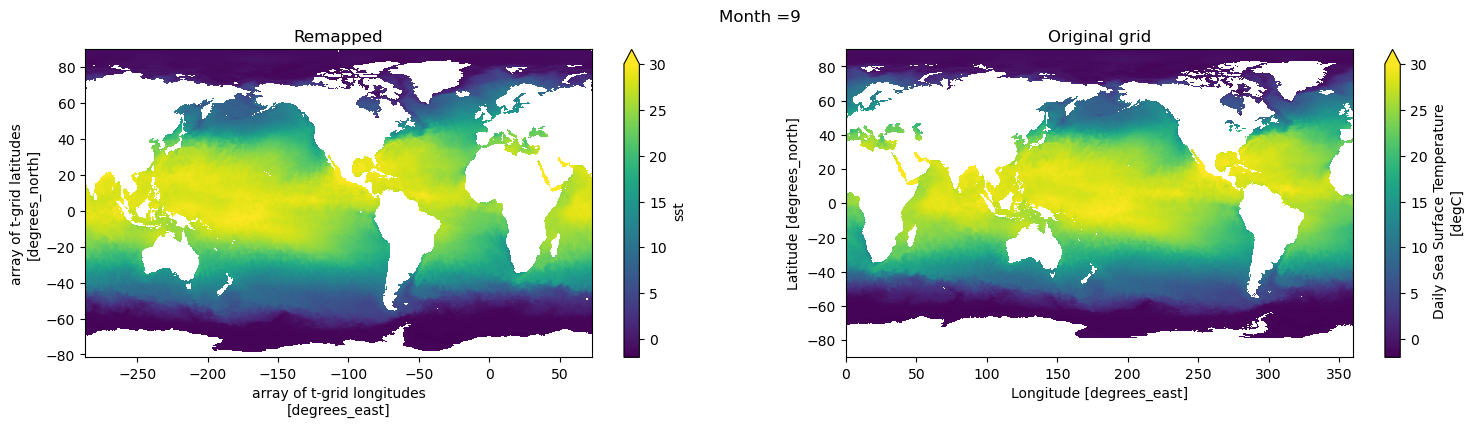

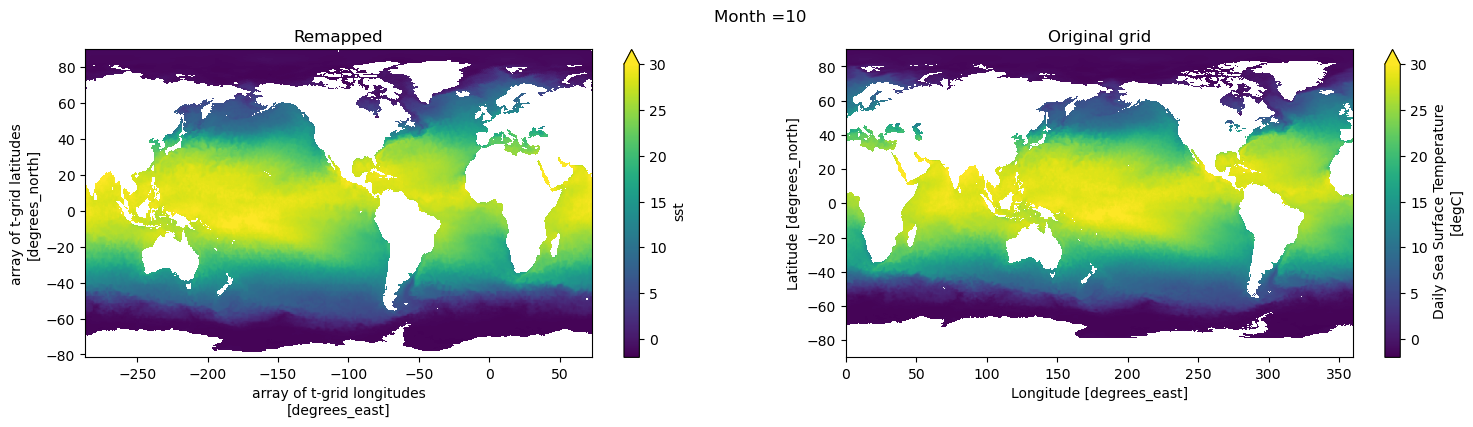

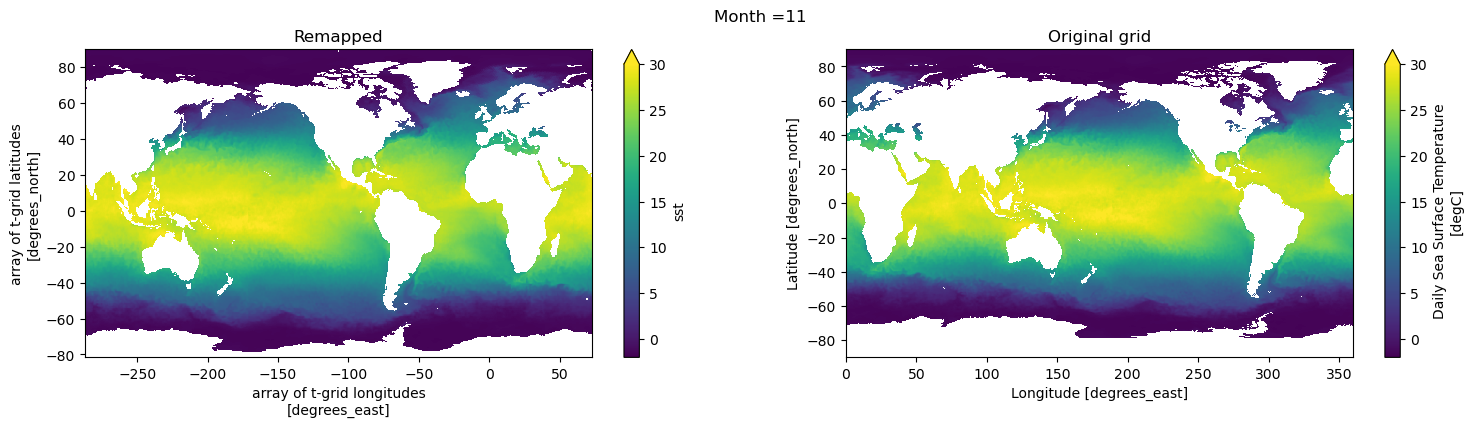

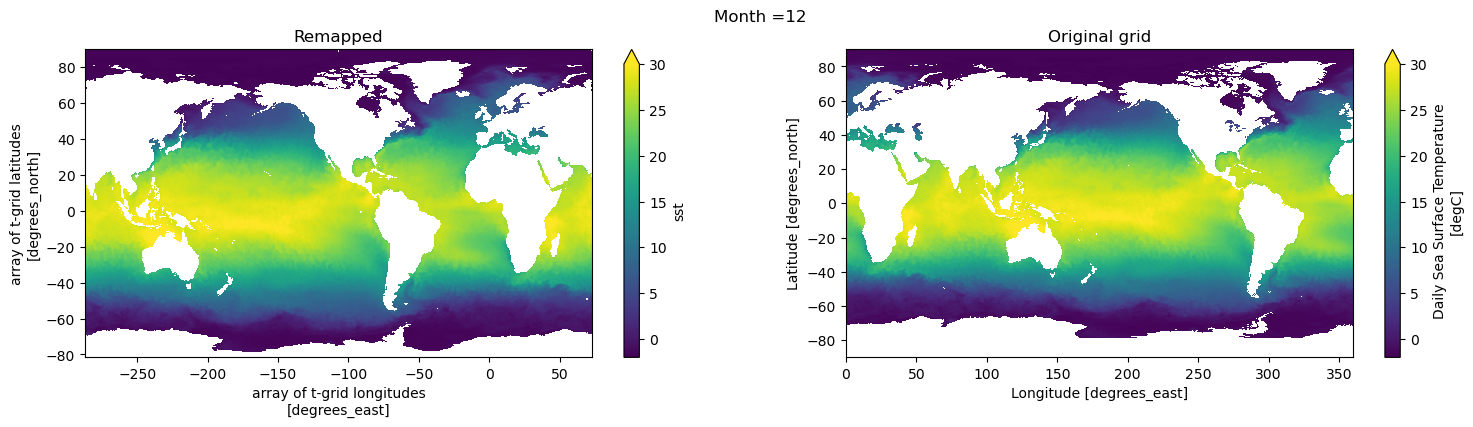

In [9]:
# visual inspection. Make sure original and remapped plots look similar
for t in range(12):
  fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18,4))
  sst[t,:,:].plot.pcolormesh(x='geolon',y='geolat',ax=axes[0], vmin=-2,vmax=30)
  ds_in['sst'][t,:,:].plot.pcolormesh(ax=axes[1], vmin=-2,vmax=30)
  axes[0].set_title('Remapped')
  axes[1].set_title('Original grid')
  plt.suptitle('Month ='+ str(t+1))

In [10]:
# Global attrs
sst.attrs['title'] = 'Monthly OISSTv2 remapped to tx2_3v3'
sst.attrs['references'] = 'https://www.esrl.noaa.gov/psd/data/gridded/data.noaa.oisst.v2.highres.html'
sst.attrs['author'] = 'Gustavo Marques (gmarques@ucar.edu)'
sst.attrs['date'] = today
sst.attrs['infile'] = infile
sst.attrs['url'] = 'https://github.com/NCAR/tx2_3/oisst'
# save
fname = 'oisstv2_to_tx2_3v3_{}.nc'.format(today)
sst.to_netcdf(fname)